In [2]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 1. 读取数据
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='root',
    database='ads_db',
    charset='utf8mb4'
)
df = pd.read_sql("""
    SELECT customer_name, stat_date, order_amt, paid_amt
    FROM ads_sale_analysis
    WHERE customer_name != 'UNKNOWN'
""", conn)
conn.close()

print(f"客户数: {df['customer_name'].nunique()}")


C:\Users\q2898\AppData\Local\Temp\ipykernel_16296\3309884513.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


客户数: 28


In [4]:
# 2. 计算 RFM
end_date = df['stat_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_name').agg({
    'stat_date': lambda x: (end_date - x.max()).days,
    'order_amt': ['sum', 'count'],
    'paid_amt': 'sum'
})
rfm.columns = ['recency', 'monetary', 'frequency', 'paid']
rfm = rfm.fillna(0)
rfm.head()


,recency,monetary,frequency,paid
customer_name,,,,
TCL电子科技股份,1,34768892.67,698,24249419.53
三一重工设备制造,1,48319066.65,974,35033611.99
上海电气集团股份,1,30714772.63,594,20222475.23
东方电气股份公司,1,61966634.85,1240,42437751.55
中兴通讯科技集团,1,31453001.65,620,23382906.02


In [5]:
# ============================================================
# 3. RFM 打分（百分位法：按数据自身分布五等分）
# ============================================================
# 说明：固定档位（如下单 2/4/8 次、金额 5万/15万/30万）在数据量级变化时
#   会失真（曾导致所有客户同分、全部落入同一层）。此处改为按每个指标
#   自身分布打 1~5 分：频率/金额越高分越高；最近消费间隔越短分越高。
def score_by_quintile(s, higher_is_better=True):
    """把序列按分位排名映射为 1~5 分。
    higher_is_better=True：值越大分越高（频率、金额）；
    higher_is_better=False：值越小分越高（最近消费间隔 recency）。"""
    x = s if higher_is_better else -s
    pct = x.rank(pct=True) * 100            # 0~100，值越大 pct 越大
    return (pct // 20).astype(int).clip(0, 4) + 1


rfm['r'] = score_by_quintile(rfm['recency'], higher_is_better=False)
rfm['f'] = score_by_quintile(rfm['frequency'], higher_is_better=True)
rfm['m'] = score_by_quintile(rfm['monetary'], higher_is_better=True)
rfm['total'] = rfm['r'] + rfm['f'] + rfm['m']

print('RFM 打分结果（r/f/m 均为 1~5 分）：')
print(rfm[['r', 'f', 'm', 'total']].describe().round(2))
rfm[['r', 'f', 'm', 'total']].head()


RFM 打分结果（r/f/m 均为 1~5 分）：
           r      f      m  total
count  28.00  28.00  28.00  28.00
mean    2.79   3.07   3.07   8.93
std     0.63   1.44   1.44   3.14
min     1.00   1.00   1.00   3.00
25%     3.00   2.00   2.00   6.50
50%     3.00   3.00   3.00   9.00
75%     3.00   4.00   4.00  11.00
max     3.00   5.00   5.00  13.00


,r,f,m,total
customer_name,,,,
TCL电子科技股份,3,2,2,7
三一重工设备制造,3,4,3,10
上海电气集团股份,3,2,2,7
东方电气股份公司,3,4,4,11
中兴通讯科技集团,3,2,2,7


In [6]:
def classify(score):
    if score >= 13: return '高价值客户'
    elif score >= 10: return '核心客户'
    elif score >= 7: return '普通客户'
    else: return '低价值客户'

rfm['level'] = rfm['total'].apply(classify)
print(rfm['level'].value_counts())

level
普通客户     8
核心客户     7
低价值客户    7
高价值客户    6
Name: count, dtype: int64


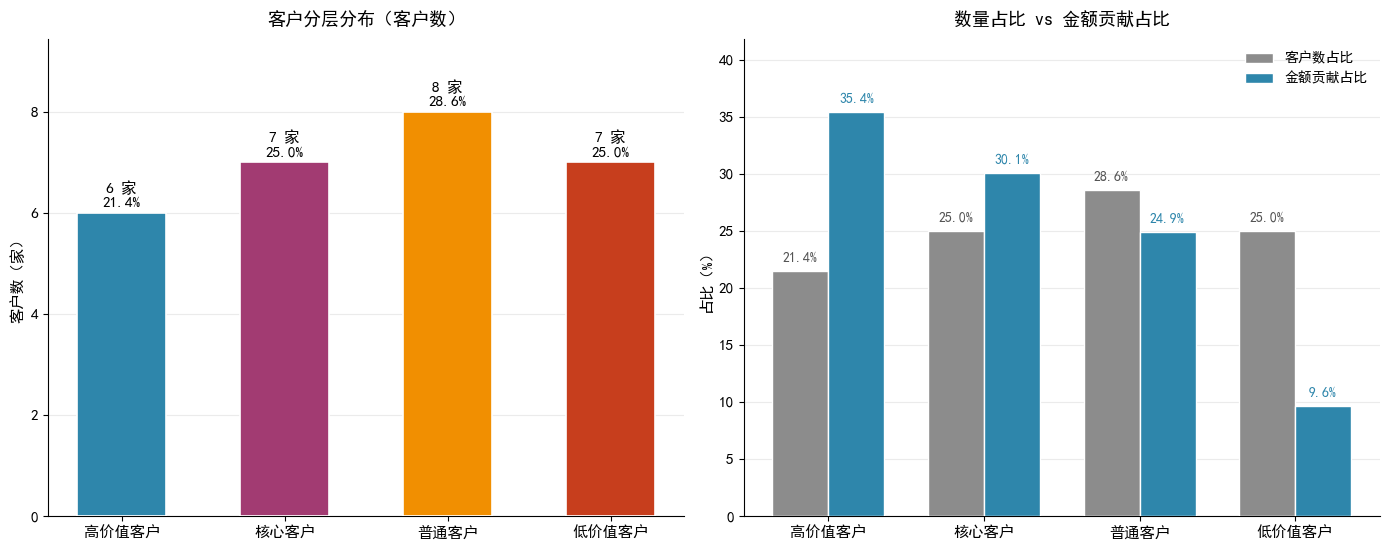

✅ 图表已保存：bi/analysis/rfm_result.png
💡 高价值客户 6 家（21.4%）贡献了 35.4% 的订单金额。


In [7]:
# ============================================================
# 5. 可视化①：客户分层结构（客户数分布 + 金额贡献对比）
# ============================================================
import numpy as np

LEVELS = ['高价值客户', '核心客户', '普通客户', '低价值客户']
COLORS = {'高价值客户': '#2E86AB', '核心客户': '#A23B72',
          '普通客户': '#F18F01', '低价值客户': '#C73E1D'}

counts = rfm['level'].value_counts().reindex(LEVELS).fillna(0).astype(int)
present = [l for l in LEVELS if counts[l] > 0]
amt = rfm.groupby('level')['monetary'].sum().reindex(LEVELS).fillna(0)
n_total = int(counts.sum())
amt_total = float(amt.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# —— 左图：各层级客户数（含占比）——
ax = axes[0]
bars = ax.bar(present, [counts[l] for l in present],
              color=[COLORS[l] for l in present], width=0.55,
              edgecolor='white', linewidth=1.2, zorder=3)
for b, l in zip(bars, present):
    share = counts[l] / n_total * 100
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(counts.values) * 0.01,
            f"{counts[l]} 家\n{share:.1f}%", ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('客户分层分布（客户数）', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('客户数（家）', fontsize=11)
ax.set_ylim(0, max(counts.values) * 1.18)
ax.grid(axis='y', color='#E3E3E3', linewidth=0.8, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.tick_params(labelsize=11)

# —— 右图：客户数占比 vs 金额贡献占比 ——
ax = axes[1]
x = np.arange(len(present))
w = 0.36
cnt_share = np.array([counts[l] / n_total * 100 for l in present])
amt_share = np.array([amt[l] / amt_total * 100 for l in present])
b1 = ax.bar(x - w / 2, cnt_share, w, label='客户数占比', color='#8C8C8C',
            edgecolor='white', zorder=3)
b2 = ax.bar(x + w / 2, amt_share, w, label='金额贡献占比', color='#2E86AB',
            edgecolor='white', zorder=3)
for xi, v in zip(x - w / 2, cnt_share):
    ax.text(xi, v + 0.8, f'{v:.1f}%', ha='center', fontsize=10, color='#555555')
for xi, v in zip(x + w / 2, amt_share):
    ax.text(xi, v + 0.8, f'{v:.1f}%', ha='center', fontsize=10,
            color='#2E86AB', fontweight='bold')
ax.set_xticks(x, present, fontsize=11)
ax.set_title('数量占比 vs 金额贡献占比', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('占比（%）', fontsize=11)
ax.set_ylim(0, max(cnt_share.max(), amt_share.max()) * 1.18)
ax.grid(axis='y', color='#E3E3E3', linewidth=0.8, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, frameon=False, loc='upper right')
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('bi/analysis/rfm_result.png', dpi=150, bbox_inches='tight')
plt.show()

# —— 读图结论（自动生成）——
top_l = present[0]
print('✅ 图表已保存：bi/analysis/rfm_result.png')
print(f'💡 {top_l} {counts[top_l]} 家（{counts[top_l] / n_total * 100:.1f}%）'
      f'贡献了 {amt[top_l] / amt_total * 100:.1f}% 的订单金额。')


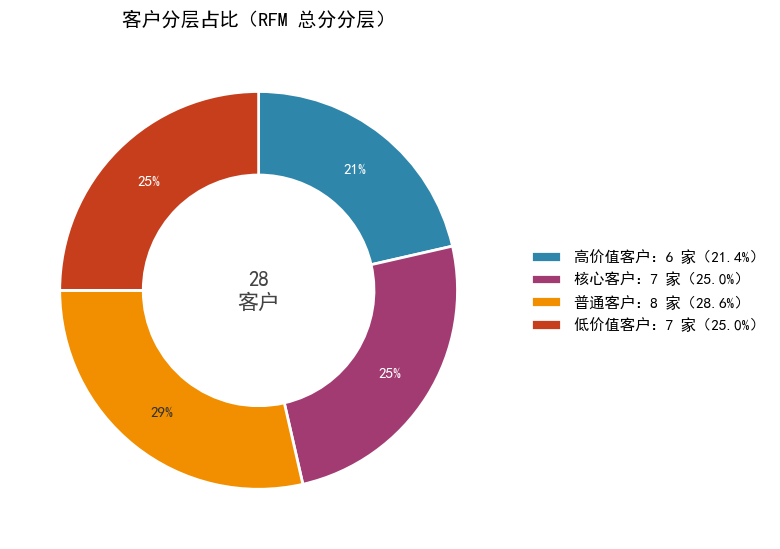

✅ 图表已保存：bi/analysis/rfm_pie.png


In [8]:
# ============================================================
# 6. 可视化②：客户分层占比（环形图）
# ============================================================
LEVELS = ['高价值客户', '核心客户', '普通客户', '低价值客户']
COLORS = {'高价值客户': '#2E86AB', '核心客户': '#A23B72',
          '普通客户': '#F18F01', '低价值客户': '#C73E1D'}

counts6 = rfm['level'].value_counts().reindex(LEVELS).fillna(0).astype(int)
present6 = [l for l in LEVELS if counts6[l] > 0]
vals6 = [counts6[l] for l in present6]
n_total6 = int(counts6.sum())

fig, ax = plt.subplots(figsize=(7.6, 5.6))
wedges, _, autotexts = ax.pie(
    vals6, labels=None, startangle=90, counterclock=False,
    colors=[COLORS[l] for l in present6],
    autopct=lambda p: f'{p:.0f}%' if p >= 4 else '',
    pctdistance=0.78, textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 2})

# 浅色扇区（普通客户/橙）用深色文字，深色扇区用白字
for t, l in zip(autotexts, present6):
    t.set_color('#333333' if COLORS[l] in ('#F18F01',) else 'white')

ax.text(0, 0, f'{n_total6}\n客户', ha='center', va='center',
        fontsize=15, fontweight='bold', color='#444444')
ax.legend(wedges,
          [f'{l}：{counts6[l]} 家（{counts6[l] / n_total6 * 100:.1f}%）'
           for l in present6],
          loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=11)
ax.set_title('客户分层占比（RFM 总分分层）', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('bi/analysis/rfm_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 图表已保存：bi/analysis/rfm_pie.png')
